## Análisis y Predicción de Supervivencia en el Titanic

Este notebook contiene un análisis del conjunto de datos del Titanic, incluyendo la limpieza de datos, exploración y la construcción de un modelo de regresión logística para predecir la supervivencia.

In [1]:
#Titanic Kaggle

### Carga de Datos

Esta celda importa la librería pandas y carga el archivo `train.csv` en un DataFrame llamado `datos`. Este es el primer paso para comenzar el análisis de datos.

In [2]:
import pandas as pd
datos = pd.read_csv("train.csv")

### Exploración Inicial de Datos (Head)

Esta celda muestra las primeras filas del DataFrame `datos`. Esto es útil para obtener una vista rápida de la estructura del dataset, las columnas disponibles y el tipo de datos que contienen.

In [3]:
datos.head

<bound method NDFrame.head of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ...    ...   
886                              Montvila, Rev. Juozas    male  27.0      0   
887                       Graham, Miss. Margaret Edith  female  19.0      0   
888           Johnston, Miss. Catherine Helen "Carrie"  female   NaN      1   
889                              Behr, Mr. Karl Howell    male  26.0      0   
890                                Dooley, Mr. Patrick    male  32.0      0   

     Parch            Ticket     Fare Cabin Embarked  
0        0         A/5 21171   7.2500   NaN        S  
1        0          PC 17599  71.2833   C85        C  
2        0  STON/O2. 3101282   7.9250   NaN        S  
3        0            113803  53.1000  C123        S  
4        0            373450   8.0500   NaN        S  
..     ...               ...      ...   ...      ...  
886      0            211536  13.0000   NaN        S  
887      0            112053  30.0000   B42        S  
888      2        W./C. 6607  23.4500   NaN        S  
889      0            111369  30.0000  C148        C  
890      0            370376   7.7500   NaN        Q  

[891 rows x 12 columns]>

### Estadísticas Descriptivas

Esta celda genera estadísticas descriptivas de las columnas numéricas en el DataFrame. Proporciona información como la cuenta, la media, la desviación estándar, los valores mínimos y máximos, y los cuartiles, lo que ayuda a entender la distribución de los datos.

In [4]:
datos.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Visualización de Supervivencia

Esta celda importa la librería `seaborn` para la visualización de datos y crea un gráfico de barras (countplot) que muestra el número de pasajeros que sobrevivieron (`Survived=1`) y los que no (`Survived=0`).

<Axes: xlabel='Survived', ylabel='count'>

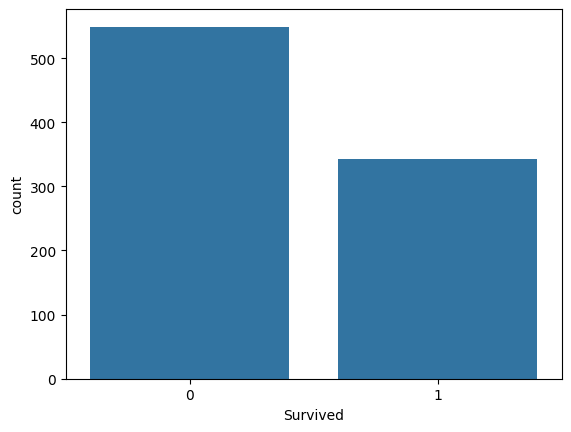

In [5]:
import seaborn as sb
sb.countplot(x="Survived", data=datos)

### Supervivencia por Género

Esta celda expande la visualización anterior, mostrando la distribución de la supervivencia (`Survived`) pero segmentada por género (`Sex`). Esto permite observar si hay una diferencia en las tasas de supervivencia entre hombres y mujeres.

<Axes: xlabel='Survived', ylabel='count'>

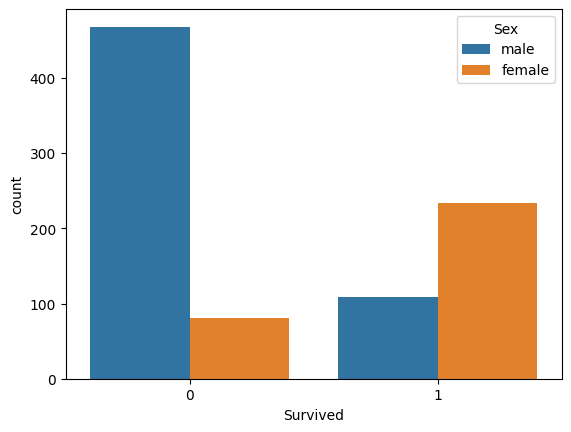

In [6]:
sb.countplot(x="Survived", hue="Sex", data=datos)

### Verificación de Valores Faltantes

Esta celda calcula la suma de valores nulos (NaN) para cada columna en el DataFrame. Es un paso crucial en la limpieza de datos para identificar qué columnas tienen datos faltantes y cuántos.

In [7]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Distribución de Edades

Esta celda crea un histograma (displot) de la columna 'Age' (Edad) utilizando `seaborn`. Esto ayuda a visualizar la distribución de edades de los pasajeros en el dataset.

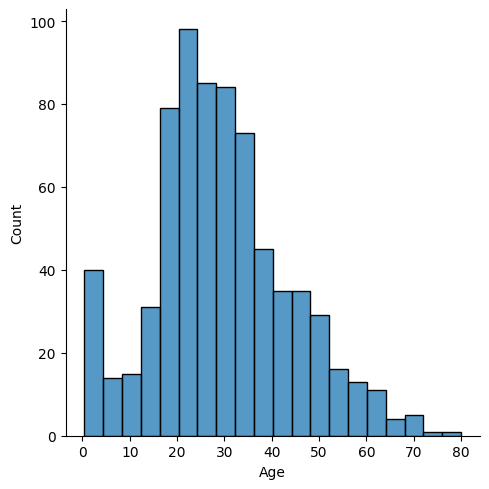

In [8]:
sb.displot(x="Age", data=datos)

### Selección de la Columna 'Age'

Esta celda simplemente muestra el contenido de la columna 'Age' del DataFrame, incluyendo los valores nulos que se identificaron previamente.

In [9]:
datos["Age"]

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


### Cálculo de la Media de la Edad

Esta celda calcula el valor medio (promedio) de la columna 'Age'. Este valor se utilizará para rellenar los datos faltantes en esta columna.

In [10]:
datos["Age"].mean()

np.float64(29.69911764705882)

### Rellenar Valores Faltantes en 'Age' (Vista Previa)

Esta celda muestra cómo se vería la columna 'Age' si se rellenaran los valores nulos con la media calculada, pero sin aplicar los cambios permanentemente al DataFrame.

In [11]:
datos["Age"].fillna(datos["Age"].mean())

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


### Rellenar Valores Faltantes en 'Age' (Aplicar Cambios)

Esta celda aplica permanentemente el relleno de los valores nulos en la columna 'Age' con el valor medio previamente calculado.

In [12]:
datos["Age"] = datos["Age"].fillna(datos["Age"].mean())

### Verificación de 'Age' Actualizada

Esta celda muestra la columna 'Age' después de haber rellenado los valores nulos, confirmando que ya no hay `NaN` en esta columna.

In [13]:
datos["Age"]

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


### Re-verificación de Valores Faltantes

Esta celda verifica nuevamente la suma de valores nulos para cada columna para asegurarse de que la columna 'Age' ya no tiene valores faltantes y para identificar si quedan otros nulos.

In [14]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### Eliminación de la Columna 'Cabin'

Esta celda elimina la columna 'Cabin' del DataFrame, ya que tiene una gran cantidad de valores faltantes y puede no ser útil para el modelo. `axis=1` indica que se está eliminando una columna.

In [15]:
datos = datos.drop("Cabin", axis=1)

### Conteo de Valores en 'Embarked'

Esta celda cuenta la frecuencia de cada valor único en la columna 'Embarked' (puerto de embarque). Esto es útil para entender la distribución de los puertos y para decidir cómo manejar los valores faltantes si los hubiera.

In [16]:
datos["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


### Eliminación de Filas con Valores Faltantes

Esta celda elimina todas las filas que aún contengan algún valor nulo después de haber tratado la columna 'Age' y eliminado 'Cabin'. Esto asegura que el dataset esté limpio para el modelado.

In [17]:
datos = datos.dropna()

### Vista Previa del DataFrame Limpio

Esta celda muestra las primeras filas del DataFrame después de todas las operaciones de limpieza y eliminación de columnas, confirmando el estado actual de los datos.

In [18]:
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


### Eliminación de Columnas Irrelevantes

Esta celda elimina las columnas 'Name', 'PassengerId' y 'Ticket', ya que se consideran irrelevantes para la predicción de supervivencia y no aportan información significativa al modelo.

In [19]:
datos = datos.drop(["Name", "PassengerId", "Ticket"], axis=1)

### Creación de Variables Dummy para 'Sex'

Esta celda convierte la columna categórica 'Sex' en variables dummy (binarias) utilizando `pd.get_dummies`. `drop_first=True` evita la multicolinealidad, creando solo una columna (`male`) para representar ambos géneros.

In [20]:
dummies_sex = pd.get_dummies(datos["Sex"], drop_first=True)

### Integración de Variables Dummy 'Sex'

Esta celda une las variables dummy de 'Sex' al DataFrame principal y luego elimina la columna original 'Sex'. Esto transforma la característica 'Sex' en un formato numérico adecuado para el modelo.

In [21]:
datos = datos.join(dummies_sex)
datos = datos.drop(["Sex"], axis=1)

### Supervivencia por Puerto de Embarque

Esta celda genera un gráfico de barras que muestra la distribución de la supervivencia (`Survived`) según el puerto de embarque (`Embarked`). Esto ayuda a visualizar si el puerto de origen influye en la tasa de supervivencia.

<Axes: xlabel='Survived', ylabel='count'>

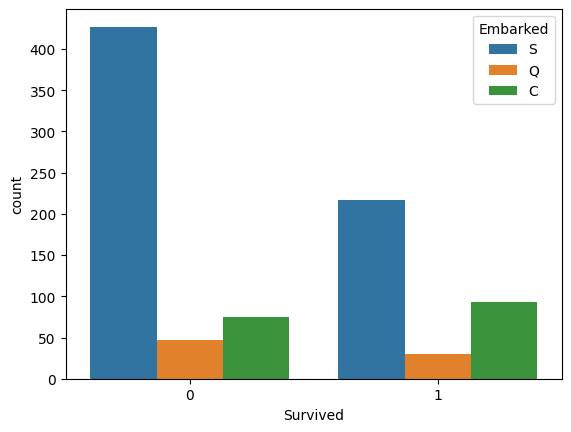

In [22]:
sb.countplot(x="Survived", data=datos, hue="Embarked")

### Creación de Variables Dummy para 'Embarked'

Esta celda crea variables dummy para la columna categórica 'Embarked', representando los diferentes puertos de embarque. `drop_first=True` se utiliza nuevamente para evitar la multicolinealidad.

In [23]:
dummies_embarked = pd.get_dummies(datos["Embarked"], drop_first=True)

### Integración de Variables Dummy 'Embarked'

Esta celda une las variables dummy de 'Embarked' al DataFrame y luego elimina la columna original 'Embarked', completando la transformación de esta característica categórica a numérica.

In [24]:
datos = datos.join(dummies_embarked)
datos = datos.drop(["Embarked"], axis=1)

### Mapa de Calor de Correlación

Esta celda genera un mapa de calor que visualiza la matriz de correlación entre todas las columnas numéricas del DataFrame. `annot=True` muestra los valores de correlación y `cmap='YlGnBu'` define la paleta de colores.

<Axes: >

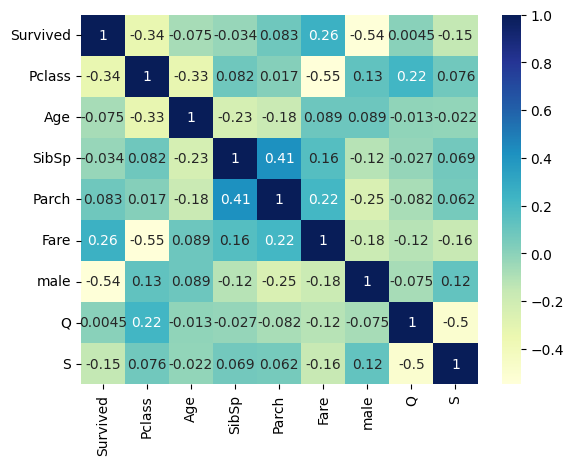

In [26]:
sb.heatmap(datos.corr(), annot=True, cmap="YlGnBu")

### Supervivencia por Clase de Pasajero

Esta celda crea un gráfico de barras para analizar la relación entre la supervivencia (`Survived`) y la clase de pasajero (`Pclass`). Esto puede indicar si la clase social influyó en las posibilidades de supervivencia.

<Axes: xlabel='Survived', ylabel='count'>

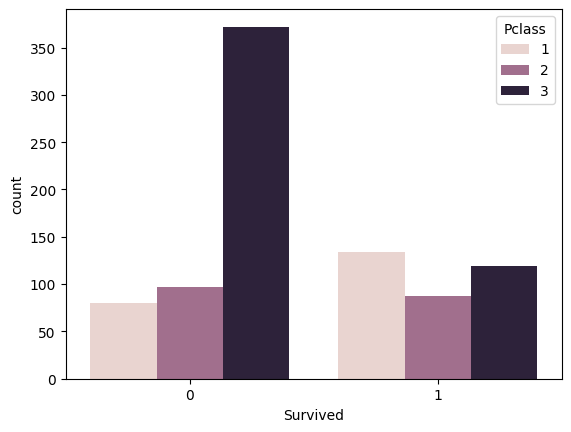

In [27]:
sb.countplot(x="Survived", data=datos, hue="Pclass")

### Separación de Características y Variable Objetivo

Esta celda divide el DataFrame en dos partes: `X` que contiene las características (variables independientes) utilizadas para la predicción, y `y` que contiene la variable objetivo (`Survived`).

In [31]:
X = datos.drop(["Survived"], axis=1)
y = datos["Survived"]

### División de Datos en Conjuntos de Entrenamiento y Prueba

Esta celda importa la función `train_test_split` de `sklearn.model_selection` para dividir `X` y `y` en conjuntos de entrenamiento y prueba. `test_size=.2` significa que el 20% de los datos se utilizará para pruebas.

In [32]:
from sklearn.model_selection import train_test_split

X_ent, X_pru, y_ent, y_pru = train_test_split(X, y, test_size=.2)

### Entrenamiento del Modelo de Regresión Logística

Esta celda importa `LogisticRegression` de `sklearn.linear_model`, inicializa un modelo con `max_iter=1000` y luego lo entrena utilizando los datos de entrenamiento (`X_ent`, `y_ent`).

In [33]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_ent, y_ent)

LogisticRegression(max_iter=1000)

### Realización de Predicciones

Esta celda utiliza el modelo entrenado para hacer predicciones (`predicciones`) sobre el conjunto de datos de prueba (`X_pru`).

In [34]:
predicciones = modelo.predict(X_pru)

### Cálculo de la Precisión del Modelo

Esta celda importa `accuracy_score` de `sklearn.metrics` y calcula la precisión del modelo comparando las predicciones (`predicciones`) con los valores reales del conjunto de prueba (`y_pru`).

In [35]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pru, predicciones)

0.8370786516853933

### Reporte de Clasificación

Esta celda importa `classification_report` y muestra un informe detallado de las métricas de rendimiento del modelo, incluyendo precisión, recall y f1-score para cada clase (0 y 1).

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_pru, predicciones))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       120
           1       0.76      0.72      0.74        58

    accuracy                           0.84       178
   macro avg       0.82      0.81      0.81       178
weighted avg       0.84      0.84      0.84       178



### Matriz de Confusión

Esta celda importa `confusion_matrix` y genera la matriz de confusión del modelo, que muestra el número de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

In [37]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_pru, predicciones)

array([[107,  13],
       [ 16,  42]])

### Visualización de la Matriz de Confusión en DataFrame

Esta celda convierte la matriz de confusión en un DataFrame de pandas para una visualización más legible, con etiquetas claras para 'Pred: No/Si' y 'Real: No/Si'.

In [41]:
pd.DataFrame(confusion_matrix(y_pru, predicciones), columns=["Pred: No", "Pred: Si"], index=["Real: No", "Real: Si"])

,Pred: No,Pred: Si
Real: No,107,13
Real: Si,16,42


### Vista Previa de las Características (X)

Esta celda muestra las primeras filas del DataFrame `X` (características), que es el conjunto de datos que se usa como entrada para las predicciones del modelo. Esto ayuda a recordar la estructura de las características.

In [43]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


### Predicción para una Nueva Persona

Esta celda simula una nueva persona con características específicas y utiliza el modelo entrenado para predecir si esta persona sobreviviría o no. Luego imprime el resultado de la predicción.

In [44]:
nueva_persona = [3, 35, 0, 0, 10, 1, 00, 0]
prediccion = modelo.predict([nueva_persona])
if prediccion[0] == 1:
  print("Sobreviviste")
else:
  print("No sobreviviste")

No sobreviviste


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# "Joven haga su trabajo por favor"

###### 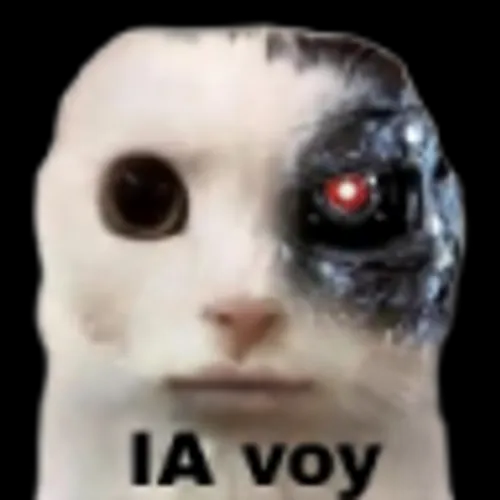